## Cell 1: 환경 설정 (Drive, GPU)


In [1]:
# [Cell 1] 기본 환경 설정
import os, sys, json, time
import numpy as np
import matplotlib.pyplot as plt

import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("WARNING: GPU 없음 -- 런타임을 GPU로 설정하세요")
print(f"Device: {device}")


GPU: NVIDIA RTX A5000
VRAM: 25.4 GB
Device: cuda


## 🟢 Cell 2: 파일 복사 및 패치 (Patching)

In [2]:
# [Cell 2] 코드 파일 세팅 및 모듈 임포트
import shutil, os, sys

# 노트북과 같은 폴더에 .py 파일들이 있다고 가정
CODE_DIR = os.getcwd()
SAVE_DIR = os.path.join(CODE_DIR, "checkpoints_wrn28_12_scratch")
LOG_FILE = os.path.join(CODE_DIR, "log_wrn28_12_scratch.json")

os.makedirs(SAVE_DIR, exist_ok=True)

# 괄호 포함 파일명은 Python에서 직접 import 불가 -> 이름 복사
for src, dst in [("model(28_12).py", "model_wrn.py"), ("trainer(28_12).py", "trainer_wrn.py")]:
    if not os.path.exists(dst):
        shutil.copy(src, dst)

# 모듈 임포트 및 apply_mix_aug 패치
from dataloader import get_dataloaders
from model_wrn import WideResNet, SAM

import trainer
import trainer_wrn
trainer.apply_mix_aug = trainer_wrn.apply_mix_aug
from trainer import train_one_epoch

print(f"✅ 파일 세팅 및 모델/유틸리티 로드 완료")
print(f"SAVE_DIR : {SAVE_DIR}")


✅ 파일 세팅 및 모델/유틸리티 로드 완료
SAVE_DIR : /data/checkpoints_wrn28_12_scratch


##🟢 Cell 3: 유틸리티 및 실험 실행 함수 (수정됨)

In [ ]:
# [Cell 3] 유틸리티 및 run_experiment (Hierarchical Loss + Top-5 SC 평가)
import torch.nn as nn
import torch.nn.functional as F
from torch.optim.lr_scheduler import CosineAnnealingLR, LinearLR, SequentialLR
from tqdm import tqdm
import time
import torch
import os
import json

def set_seed(seed):
    import random
    import numpy as np
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

def build_scheduler(optimizer_base, sched, epochs, warmup_ep=5):
    if sched == 'wcos':
        warmup = LinearLR(optimizer_base, start_factor=0.01, end_factor=1.0, total_iters=warmup_ep)
        cosine = CosineAnnealingLR(optimizer_base, T_max=epochs - warmup_ep, eta_min=1e-6)
        return SequentialLR(optimizer_base, schedulers=[warmup, cosine], milestones=[warmup_ep])
    return CosineAnnealingLR(optimizer_base, T_max=epochs, eta_min=1e-6)

def build_optimizer(model, cfg):
    if cfg['opt'] == 'sam':
        optimizer = SAM(model.parameters(), base_optimizer=torch.optim.SGD,
                        rho=cfg['rho'], lr=cfg['lr'], momentum=0.9,
                        weight_decay=cfg['wd'], nesterov=True)
        return optimizer, 'sam'
    base = torch.optim.SGD(model.parameters(), lr=cfg['lr'], momentum=0.9, weight_decay=cfg['wd'], nesterov=True)
    return base, 'sgd'

class HierarchicalCELoss(nn.Module):
    def __init__(self, sc_map, smoothing=0.15, sibling_ratio=0.8):
        super().__init__()
        num_classes = len(sc_map)
        matrix = torch.zeros(num_classes, num_classes)
        for i in range(num_classes):
            sc_i = sc_map[i]
            siblings = (sc_map == sc_i).nonzero(as_tuple=True)[0]
            num_siblings = len(siblings) - 1
            num_others = num_classes - len(siblings)
            if num_others > 0:
                matrix[i, :] = smoothing * (1.0 - sibling_ratio) / num_others
            if num_siblings > 0:
                matrix[i, siblings] = smoothing * sibling_ratio / num_siblings
            matrix[i, i] = 1.0 - smoothing
        self.register_buffer('smooth_matrix', matrix)

    def forward(self, logits, targets):
        soft_targets = self.smooth_matrix[targets]
        log_preds = F.log_softmax(logits, dim=-1)
        loss = -(soft_targets * log_preds).sum(dim=-1).mean()
        return loss

def evaluate_fixed(model, loader, criterion, device, sc_map):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    sc_score_sum = 0.0
    sc_map = sc_map.to(device)

    with torch.no_grad():
        for imgs, targets, sc_targets in loader:
            imgs, targets, sc_targets = imgs.to(device), targets.to(device), sc_targets.to(device)
            outputs = model(imgs)
            logits = outputs[0]
            loss = criterion(logits, targets)
            total_loss += loss.item() * imgs.size(0)
            _, predicted = logits.max(1)
            total += targets.size(0)
            correct += predicted.eq(targets).sum().item()
            k = 5
            _, topk_pred = logits.topk(k, dim=1, largest=True, sorted=True)
            pred_sc = sc_map[topk_pred]
            target_sc_exp = sc_targets.unsqueeze(1)
            match = pred_sc.eq(target_sc_exp)
            score = match.float().sum(dim=1) / k
            sc_score_sum += score.sum().item()

    return total_loss/total, 100.*correct/total, 100.*sc_score_sum/total

def run_experiment(cfg, device):
    run_id = cfg['run_id']
    print(f"\n{'='*60}\n  Run {run_id} | {cfg['memo']}\n{'='*60}")
    set_seed(cfg['seed'])

    train_loader, val_loader, sc_map = get_dataloaders(
        data_root='./data', aug=cfg['aug'], batch_size=cfg['batch_size'], num_workers=2
    )

    model = WideResNet(
        depth=cfg['depth'], widen_factor=cfg['widen_factor'],
        dropout=cfg['dropout'], num_classes=100, embed_dim=cfg['embed_dim']
    ).to(device)

    optimizer, opt_type = build_optimizer(model, cfg)
    base_opt = optimizer.base_optimizer if opt_type == 'sam' else optimizer
    warmup_ep = max(2, int(cfg['epochs'] * 0.1))
    scheduler = build_scheduler(base_opt, cfg['sched'], cfg['epochs'], warmup_ep)

    if cfg.get('hierarchical_ls', False):
        criterion = HierarchicalCELoss(sc_map, smoothing=cfg['ls'], sibling_ratio=0.8).to(device)
        print(f"  [*] Hierarchical CE Loss 활성화 완료 (Smoothing: {cfg['ls']}, Sibling Ratio: 80%)")
    else:
        criterion = nn.CrossEntropyLoss(label_smoothing=cfg['ls'])

    latest_path = f'{SAVE_DIR}/run{run_id:02d}_latest.pth'
    best_path   = f'{SAVE_DIR}/run{run_id:02d}_best.pth'
    start_epoch = 1
    best_val_top1, best_val_sc = 0.0, 0.0

    # 기존 로그 불러오기 (재개 시 이어서 저장)
    history = []
    if os.path.exists(LOG_FILE):
        with open(LOG_FILE, 'r') as f:
            history = json.load(f)
        print(f"  [로그 복구] {LOG_FILE}에서 {len(history)}개 에폭 로드 완료")

    if os.path.exists(latest_path):
        ckpt = torch.load(latest_path, map_location=device)
        model.load_state_dict(ckpt['model_state'])
        optimizer.load_state_dict(ckpt['optimizer_state'])
        scheduler.load_state_dict(ckpt['scheduler_state'])
        start_epoch   = ckpt['epoch'] + 1
        best_val_top1 = ckpt.get('best_val_top1', 0.0)
        best_val_sc   = ckpt.get('best_val_sc',   0.0)
        print(f"  [재개] epoch {start_epoch}부터 학습 시작 (Best: {best_val_top1:.2f}%)")

    t_start = time.time()
    try:
        pbar = tqdm(range(start_epoch, cfg['epochs'] + 1), desc=f"Run {run_id} 학습 중", leave=True)
        for epoch in pbar:
            train_loss, train_acc = train_one_epoch(
                model, train_loader, optimizer, criterion, device,
                method=cfg['method'], opt_type=opt_type,
                alpha=cfg['alpha'] or 0.0, beta=cfg['beta'] or 0.0,
                loss_rule=cfg['loss_rule'], mix_aug=cfg['mix_aug'], mix_alpha=cfg['mix_alpha'],
            )

            val_loss, val_top1, val_sc = evaluate_fixed(
                model, val_loader, criterion, device, sc_map
            )

            scheduler.step()
            lr_now = base_opt.param_groups[0]['lr']

            is_best = val_top1 > best_val_top1
            if is_best:
                best_val_top1, best_val_sc = val_top1, val_sc
                torch.save({'epoch': epoch, 'model_state': model.state_dict(),
                            'val_top1': val_top1, 'val_sc': val_sc}, best_path)

            if epoch % 10 == 0 or epoch == cfg['epochs']:
                torch.save({'epoch': epoch, 'model_state': model.state_dict(), 'optimizer_state': optimizer.state_dict(),
                            'scheduler_state': scheduler.state_dict(), 'best_val_top1': best_val_top1,
                            'best_val_sc': best_val_sc}, latest_path)

            # ── JSON 로그 저장 ──────────────────────────────────────
            record = {
                'epoch': epoch,
                'loss': round(train_loss, 4),
                'train_acc': round(train_acc, 2),
                'test_top1': round(val_top1, 2),
                'test_sc': round(val_sc, 2),
                'lr': round(lr_now, 8),
            }
            history.append(record)
            with open(LOG_FILE, 'w') as f:
                json.dump(history, f, indent=2)
            # ────────────────────────────────────────────────────────

            msg = f" Ep {epoch:03d} | loss {train_loss:.4f} | train {train_acc:.2f}% | test {val_top1:.2f}% | test_SC(Top5) {val_sc:.2f}%"
            if is_best: msg += " ★"
            pbar.set_postfix({'V_Top1': f"{val_top1:.2f}%"})
            tqdm.write(msg)

    except Exception as e:
        import traceback
        print(f"\n  [ERROR] {str(e)}")
        traceback.print_exc()
    finally:
        pass

#🟢 Cell 4: 최종 스크래치 학습 실행 셀

In [ ]:
# [Cell 4] WRN-28-12 + 계층적 손실(Hierarchical Loss) 도입
import torch
from model_wrn import WideResNet

_final_scratch_config = {
    'run_id': 303,
    'memo': 'SCRATCH: WRN-28-12, BS256, Drop 0.0, Alpha 0.2, Hierarchical LS',
    'seed': 42,

    # 모델 규격
    'depth': 28,
    'widen_factor': 12,
    'dropout': 0.0,
    'embed_dim': 128,

    # 학습 파라미터
    'epochs': 300,
    'batch_size': 256,
    'lr': 0.2,
    'wd': 5e-4,

    # 계층적 라벨 스무딩 15% 적용
    'hierarchical_ls': True,
    'ls': 0.15,

    # 최적화 & 로스
    'opt': 'sam',
    'rho': 0.05,
    'sched': 'wcos',
    'method': 'emb',
    'loss_rule': 'normalized',
    'beta': 0.15,
    'alpha': None,

    # 증강 파라미터
    'aug': 'basic',
    'mix_aug': 'both',
    'mix_alpha': 0.2,
}

print(f">>> 🚀 WRN-28-12 (계층적 손실 + Embedding 시너지) 학습 가동!")
run_experiment(_final_scratch_config, device)

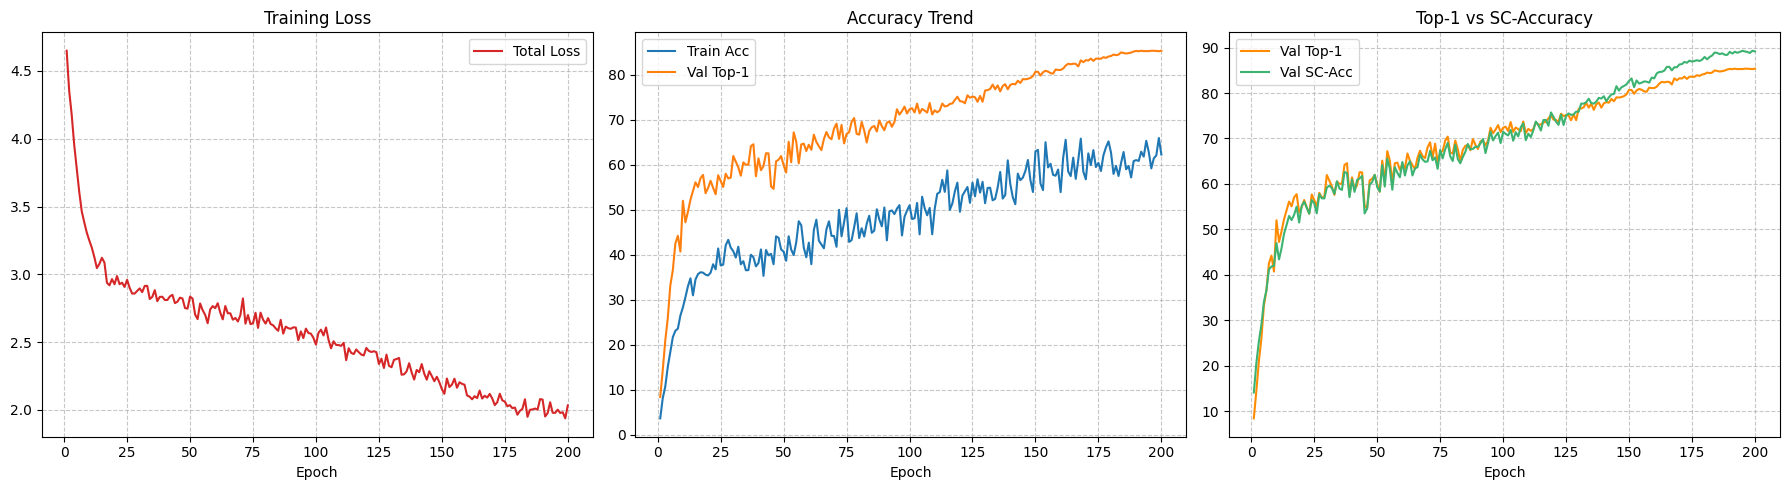

In [12]:
import matplotlib.pyplot as plt

# 데이터 로드
with open('log_wrn28_12_scratch.json', 'r') as f:
    data = json.load(f)

epochs = [d['epoch'] for d in data]
loss = [d['loss'] for d in data]
train_acc = [d['train_acc'] for d in data]
val_top1 = [d['val_top1'] for d in data]
val_sc = [d['val_sc'] for d in data]

# 시각화 (2x2 혹은 1x3 구성으로 변경)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
GRID_KW = dict(linestyle='--', alpha=0.7)

# 1. Loss 추이
axes[0].plot(epochs, loss, color='tab:red', label='Total Loss')
axes[0].set_title('Training Loss')
axes[0].set_xlabel('Epoch')
axes[0].grid(**GRID_KW)
axes[0].legend()

# 2. Train vs Val Accuracy
axes[1].plot(epochs, train_acc, label='Train Acc')
axes[1].plot(epochs, val_top1, label='Val Top-1')
axes[1].set_title('Accuracy Trend')
axes[1].set_xlabel('Epoch')
axes[1].grid(**GRID_KW)
axes[1].legend()

# 3. Val Top-1 vs SC-Accuracy (중요 지표)
axes[2].plot(epochs, val_top1, color='darkorange', label='Val Top-1')
axes[2].plot(epochs, val_sc, color='mediumseagreen', label='Val SC-Acc')
axes[2].set_title('Top-1 vs SC-Accuracy')
axes[2].set_xlabel('Epoch')
axes[2].grid(**GRID_KW)
axes[2].legend()

plt.tight_layout()
plt.show()

In [ ]:
import json
import matplotlib.pyplot as plt

with open(LOG_FILE, 'r') as f:
    history = json.load(f)

if not history:
    print("history가 비어있습니다.")
else:
    epochs     = [h['epoch']     for h in history]
    train_loss = [h['loss']      for h in history]
    train_acc  = [h['train_acc'] for h in history]
    val_top1   = [h['val_top1']  for h in history]
    val_sc     = [h['val_sc']    for h in history]

    best_top1_ep = max(history, key=lambda x: x['val_top1'])['epoch']
    best_sc_ep   = max(history, key=lambda x: x['val_sc'])['epoch']

    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle('WRN-28-12 Training Dashboard', fontsize=15, fontweight='bold', y=1.01)

    GRID_KW = dict(alpha=0.3, linestyle='--')
    BEST_KW = dict(linestyle=':', linewidth=1.5)

    ax = axes[0, 0]
    ax.plot(epochs, train_loss, color='steelblue', linewidth=1.5, label='Train Loss')
    ax.set_title('Train Loss')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.grid(**GRID_KW)
    ax.legend()

    ax = axes[0, 1]
    ax.plot(epochs, val_top1, color='darkorange', linewidth=1.5, label='Val Top-1')
    ax.axvline(best_top1_ep, color='darkorange', **BEST_KW,
               label=f'Best ep{best_top1_ep} ({max(val_top1):.2f}%)')
    ax.set_title('Val Top-1 Accuracy')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Accuracy (%)')
    ax.grid(**GRID_KW)
    ax.legend()

    ax = axes[0, 2]
    ax.plot(epochs, val_sc, color='mediumseagreen', linewidth=1.5, label='Val SC-Acc')
    ax.axvline(best_sc_ep, color='mediumseagreen', **BEST_KW,
               label=f'Best ep{best_sc_ep} ({max(val_sc):.2f}%)')
    ax.set_title('Val SC-Accuracy (Top-5 Superclass)')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('SC-Accuracy (%)')
    ax.grid(**GRID_KW)
    ax.legend()

    ax = axes[1, 0]
    ax.axis('off')

    ax = axes[1, 1]
    ax.plot(epochs, train_acc, color='steelblue',  linewidth=1.5, label='Train Acc')
    ax.plot(epochs, val_top1,  color='darkorange', linewidth=1.5, label='Val Top-1')
    gap = [t - v for t, v in zip(train_acc, val_top1)]
    ax.fill_between(epochs, train_acc, val_top1,
                    alpha=0.12, color='red', label=f'Gap (마지막 {gap[-1]:.1f}%p)')
    ax.set_title('Train vs Val Accuracy')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Accuracy (%)')
    ax.grid(**GRID_KW)
    ax.legend()

    ax = axes[1, 2]
    ax.plot(epochs, val_top1, color='darkorange',     linewidth=1.5, label='Val Top-1')
    ax.plot(epochs, val_sc,   color='mediumseagreen', linewidth=1.5, label='Val SC-Acc')
    ax.set_title('Val Top-1 vs SC-Accuracy')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Accuracy (%)')
    ax.grid(**GRID_KW)
    ax.legend()

    plt.tight_layout()
    plt.savefig('training_dashboard.png', dpi=120, bbox_inches='tight')
    plt.show()
    print(f"차트 저장 완료: training_dashboard.png ({len(history)} epochs)")